<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CustomerID  221 non-null    int64 
 1   Age         221 non-null    int64 
 2   Gender      221 non-null    object
 3   Income      221 non-null    int64 
 4   Group       221 non-null    object
 5   Response    221 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 10.5+ KB
None
       CustomerID         Age        Income    Response
count  221.000000  221.000000    221.000000  221.000000
mean   111.000000   43.981900  64914.438914    0.493213
std     63.941379   15.051718  20427.369071    0.501089
min      1.000000   18.000000  30412.000000    0.000000
25%     56.000000   31.000000  47019.000000    0.000000
50%    111.000000   44.000000  65195.000000    0.000000
75%    166.000000   57.000000  83222.000000    1.000000
max    221.000000   69.000000  99896.000000    1.000000
Group
A    119
B

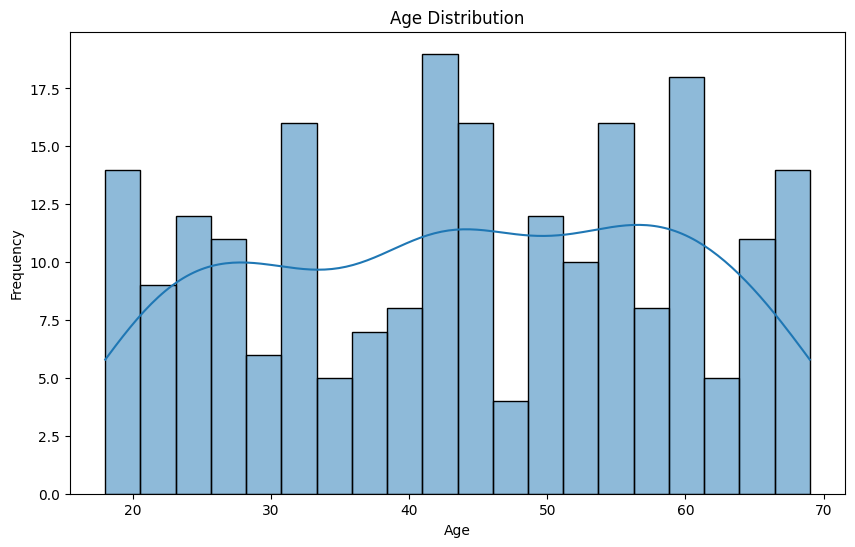

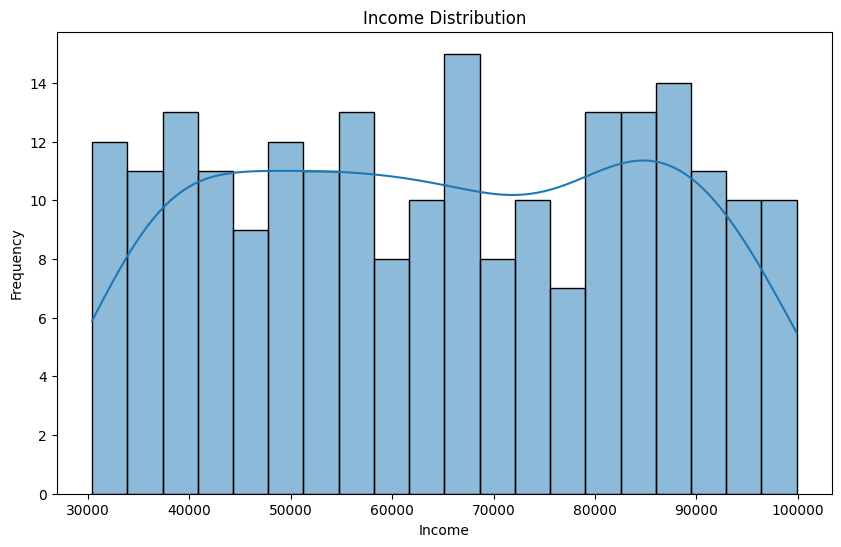

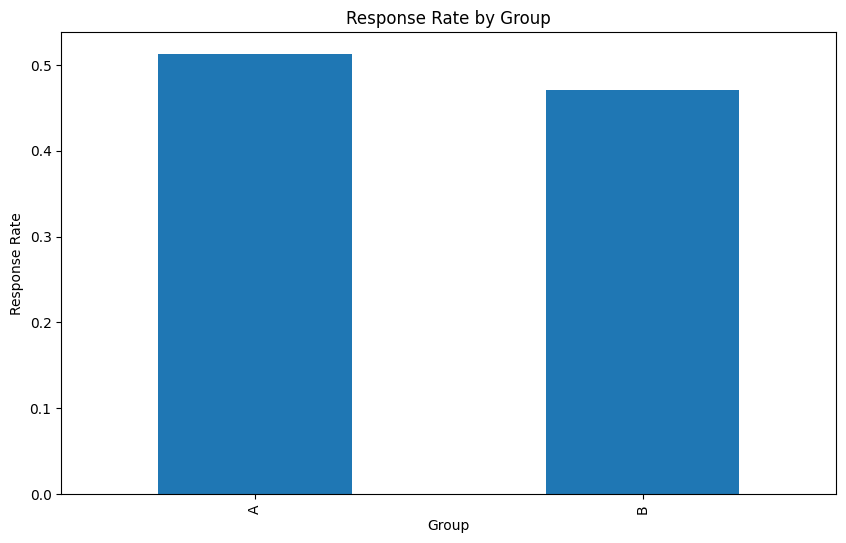

Chi-square test statistic: 0.23803136506896305
p-value: 0.6256315961272787
T-test for Age: t-statistic = 0.29659808264119375, p-value = 0.7670544693010934
T-test for Income: t-statistic = 0.5111158641574384, p-value = 0.6097848178480134


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind

# Load the dataset
df = pd.read_csv('/content/customer_ab_testing.csv')

# Display basic information about the dataset
print(df.info())
print(df.describe())
print(df['Group'].value_counts())

# Exploratory Data Analysis (EDA)
# Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Income distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Income'], bins=20, kde=True)
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

# Response rate by group
response_rate = df.groupby('Group')['Response'].mean()
response_rate.plot(kind='bar', figsize=(10, 6))
plt.title('Response Rate by Group')
plt.xlabel('Group')
plt.ylabel('Response Rate')
plt.show()

# Chi-square test for independence
contingency_table = pd.crosstab(df['Group'], df['Response'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f'Chi-square test statistic: {chi2}')
print(f'p-value: {p}')

# T-test for comparing means of Age and Income between groups
age_a = df[df['Group'] == 'A']['Age']
age_b = df[df['Group'] == 'B']['Age']
income_a = df[df['Group'] == 'A']['Income']
income_b = df[df['Group'] == 'B']['Income']

t_age, p_age = ttest_ind(age_a, age_b)
t_income, p_income = ttest_ind(income_a, income_b)
print(f'T-test for Age: t-statistic = {t_age}, p-value = {p_age}')
print(f'T-test for Income: t-statistic = {t_income}, p-value = {p_income}')
